# Business Understanding

## Problem Statement

**Customer churn is a major challenge for telecom companies because losing customers affects revenue and increases the cost of acquiring new ones. Understanding why customers leave helps businesses improve customer retention.**

## Objective
- **Analyze customer behavior and identify factors that influence churn.**
- **Build a machine learning model to predict whether a customer is likely to churn.**
- **Provide insights that can help the business improve customer retention.**

# Importing necessaary libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Connecting MYSQL

In [6]:
import mysql.connector
from getpass import getpass

password = getpass("Enter MySQL Password: ")

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password=password,
    database="telecom_churn"
)

Enter MySQL Password:  ········


In [7]:
query = """
SELECT *
FROM telecom_customers
"""

In [8]:
df = pd.read_sql(query, conn)

In [9]:
# Close the connection
conn.close()

# Data Understanding

In [11]:
df.head()

,customer_id,Gender,Age,under_30,senior_citizen,Married,Dependents,number_of_dependents,Country,State,...,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,CLTV,churn_category,churn_reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [12]:
df.sample(5)

,customer_id,Gender,Age,under_30,senior_citizen,Married,Dependents,number_of_dependents,Country,State,...,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,customer_status,churn_label,churn_score,CLTV,churn_category,churn_reason
823,4039-PIMHX,Male,74,No,Yes,Yes,No,0,United States,California,...,0,81.83,2480.23,3,Stayed,No,37,4306,,
5942,9700-ISPUP,Female,59,No,No,Yes,Yes,1,United States,California,...,0,258.90,875.80,5,Stayed,No,44,3137,,
6168,2824-MYYBN,Female,43,No,No,Yes,Yes,2,United States,California,...,0,59.20,3373.35,4,Stayed,No,29,2969,,
2020,4806-KEXQR,Male,27,Yes,No,No,No,0,United States,California,...,0,172.24,496.54,1,Churned,Yes,77,4669,Competitor,Competitor had better devices
5722,3682-YEUWS,Male,27,Yes,No,Yes,Yes,1,United States,California,...,0,41.60,295.50,5,Stayed,No,54,4458,,


In [13]:
df.shape

(7043, 50)

In [14]:
df.columns

Index(['customer_id', 'Gender', 'Age', 'under_30', 'senior_citizen', 'Married',
       'Dependents', 'number_of_dependents', 'Country', 'State', 'City',
       'zip_code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'referred_a_friend', 'number_of_referrals', 'tenure_in_months', 'Offer',
       'phone_service', 'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'internet_type', 'avg_monthly_gb_download',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_tech_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'Contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'satisfaction_score', 'customer_status', 'churn_label',
       'churn_score', 'CLTV', 'churn_category', 'churn_reason'],
      dtype='str')

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   under_30                           7043 non-null   str    
 4   senior_citizen                     7043 non-null   str    
 5   Married                            7043 non-null   str    
 6   Dependents                         7043 non-null   str    
 7   number_of_dependents               7043 non-null   int64  
 8   Country                            7043 non-null   str    
 9   State                              7043 non-null   str    
 10  City                               7043 non-null   str    
 11  zip_code                           7043 non-null   int64  
 12  Lat

In [16]:
df.describe()

,Age,number_of_dependents,zip_code,Latitude,Longitude,Population,number_of_referrals,tenure_in_months,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,churn_score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [17]:
df.describe(include="object")

,customer_id,Gender,under_30,senior_citizen,Married,Dependents,Country,State,City,Quarter,...,streaming_movies,streaming_music,unlimited_data,Contract,paperless_billing,payment_method,customer_status,churn_label,churn_category,churn_reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,1,1,1106,1,...,2,2,2,3,2,3,3,2,6,21
top,8779-QRDMV,Male,No,No,No,No,United States,California,Los Angeles,Q3,...,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Stayed,No,,
freq,1,3555,5642,5901,3641,5416,7043,7043,293,7043,...,4311,4555,4745,3610,4171,3909,4720,5174,5174,5174


In [18]:
df.isnull().sum()

customer_id                          0
Gender                               0
Age                                  0
under_30                             0
senior_citizen                       0
Married                              0
Dependents                           0
number_of_dependents                 0
Country                              0
State                                0
City                                 0
zip_code                             0
Latitude                             0
Longitude                            0
Population                           0
Quarter                              0
referred_a_friend                    0
number_of_referrals                  0
tenure_in_months                     0
Offer                                0
phone_service                        0
avg_monthly_long_distance_charges    0
multiple_lines                       0
internet_service                     0
internet_type                        0
avg_monthly_gb_download  

In [19]:
df.duplicated().sum()

0

In [20]:
df.nunique().sort_values()

Quarter                                 1
Country                                 1
State                                   1
premium_tech_support                    2
device_protection_plan                  2
online_backup                           2
online_security                         2
streaming_music                         2
internet_service                        2
multiple_lines                          2
unlimited_data                          2
phone_service                           2
referred_a_friend                       2
streaming_tv                            2
streaming_movies                        2
Dependents                              2
Gender                                  2
churn_label                             2
under_30                                2
senior_citizen                          2
Married                                 2
paperless_billing                       2
payment_method                          3
customer_status                   

In [21]:
df["churn_label"].value_counts()

churn_label
No     5174
Yes    1869
Name: count, dtype: int64

# Data Cleaning

In [23]:
df_clean = df.copy()

In [24]:
df_clean.isnull().sum().sum()

0

In [25]:
(df_clean["churn_category"].str.strip() == "").sum()

5174

In [26]:
(df_clean["churn_reason"].str.strip() == "").sum()

5174

In [27]:
df_clean.duplicated().sum()

0

In [28]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   under_30                           7043 non-null   str    
 4   senior_citizen                     7043 non-null   str    
 5   Married                            7043 non-null   str    
 6   Dependents                         7043 non-null   str    
 7   number_of_dependents               7043 non-null   int64  
 8   Country                            7043 non-null   str    
 9   State                              7043 non-null   str    
 10  City                               7043 non-null   str    
 11  zip_code                           7043 non-null   int64  
 12  Lat

In [29]:
df_clean["Age"].describe()

count    7043.000000
mean       46.509726
std        16.750352
min        19.000000
25%        32.000000
50%        46.000000
75%        60.000000
max        80.000000
Name: Age, dtype: float64

#### Data Validation

In [31]:
df_clean["Age"].describe()

count    7043.000000
mean       46.509726
std        16.750352
min        19.000000
25%        32.000000
50%        46.000000
75%        60.000000
max        80.000000
Name: Age, dtype: float64

In [32]:
df_clean["monthly_charge"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: monthly_charge, dtype: float64

In [33]:
df_clean["total_revenue"].describe()

count     7043.000000
mean      3034.379056
std       2865.204542
min         21.360000
25%        605.610000
50%       2108.640000
75%       4801.145000
max      11979.340000
Name: total_revenue, dtype: float64

In [34]:
df_clean["tenure_in_months"].describe()

count    7043.000000
mean       32.386767
std        24.542061
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure_in_months, dtype: float64

In [35]:
df_clean["satisfaction_score"].value_counts().sort_index()

satisfaction_score
1     922
2     518
3    2665
4    1789
5    1149
Name: count, dtype: int64

In [36]:
df_clean["churn_label"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

# EDA

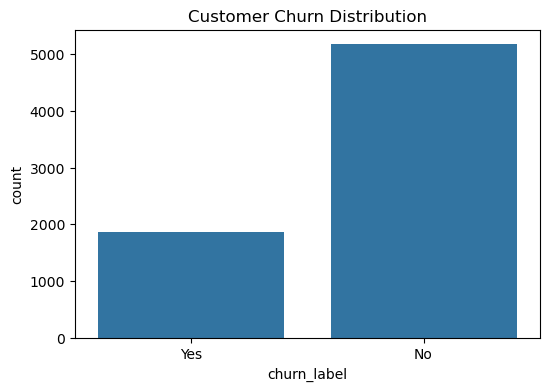

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="churn_label")
plt.title("Customer Churn Distribution")
plt.show()

<Axes: xlabel='Gender', ylabel='count'>

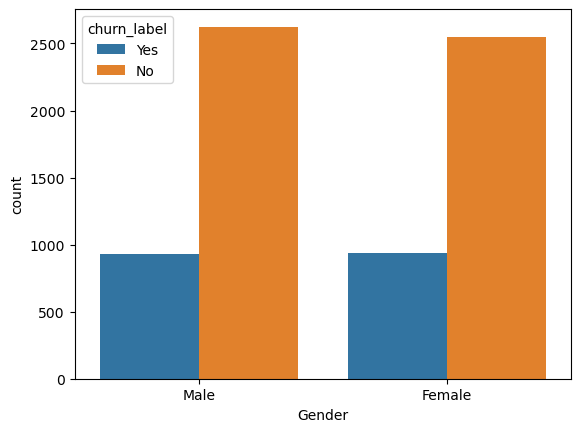

In [39]:
# Gender vs Churn
sns.countplot(
    data=df_clean,
    x="Gender",
    hue="churn_label"
)

<Axes: xlabel='churn_label', ylabel='Age'>

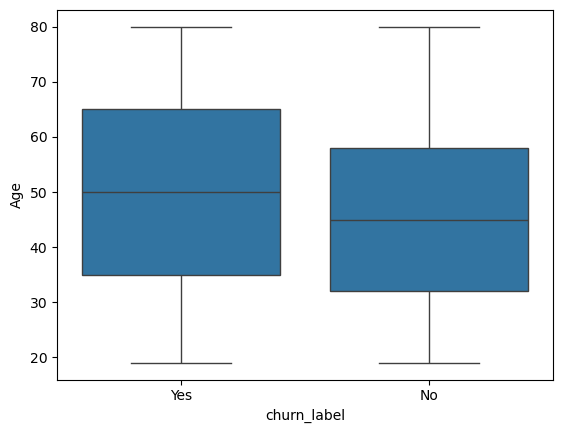

In [40]:
# Age vs Churn
sns.boxplot(
    data=df_clean,
    x="churn_label",
    y="Age"
)

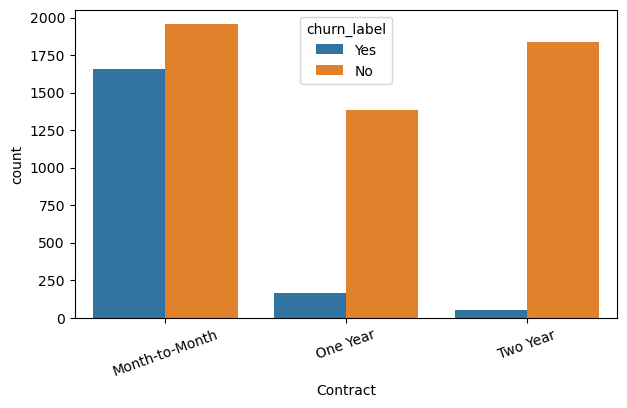

In [41]:
# Contract vs Churn
plt.figure(figsize=(7,4))

sns.countplot(
    data=df_clean,
    x="Contract",
    hue="churn_label"
)

plt.xticks(rotation=20)

plt.show()

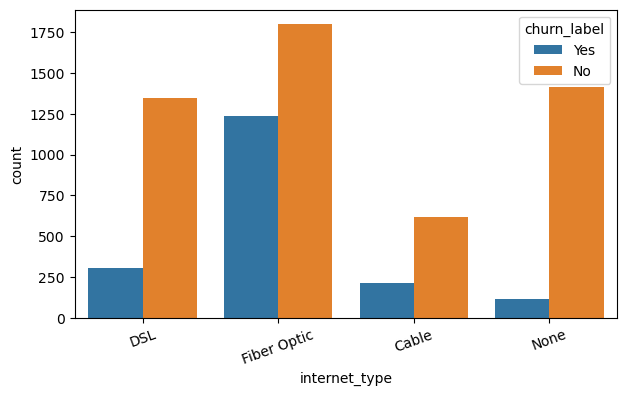

In [42]:
# Internet Type vs Churn
plt.figure(figsize=(7,4))

sns.countplot(
    data=df_clean,
    x="internet_type",
    hue="churn_label"
)

plt.xticks(rotation=20)

plt.show()

In [342]:
df_clean.groupby(["internet_service", "internet_type"]).size()

internet_service  internet_type
No                None             1526
Yes               Cable             830
                  DSL              1652
                  Fiber Optic      3035
dtype: int64

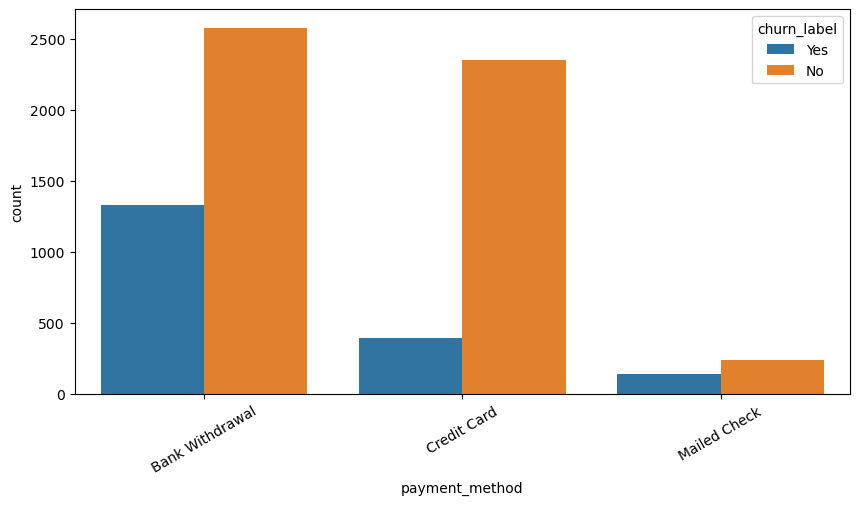

In [43]:
# Payment Method vs Churn
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="payment_method",
    hue="churn_label"
)

plt.xticks(rotation=30)

plt.show()

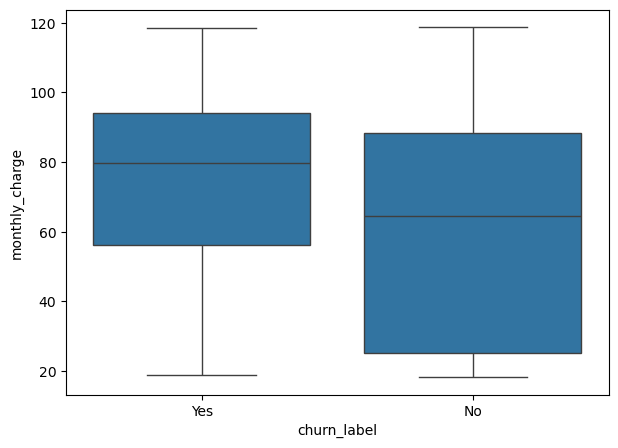

In [44]:
# Monthly Charge vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_clean,
    x="churn_label",
    y="monthly_charge"
)

plt.show()

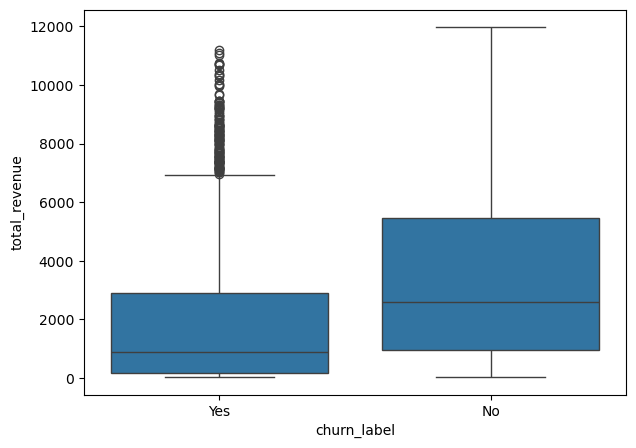

In [45]:
# Total Revenue vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_clean,
    x="churn_label",
    y="total_revenue"
)

plt.show()

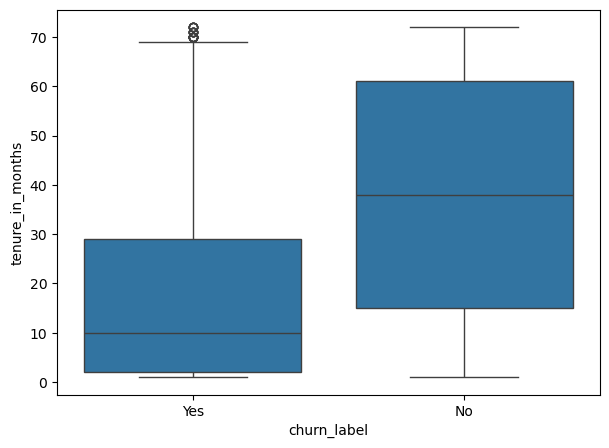

In [46]:
# Tenure vs Churn
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_clean,
    x="churn_label",
    y="tenure_in_months"
)

plt.show()

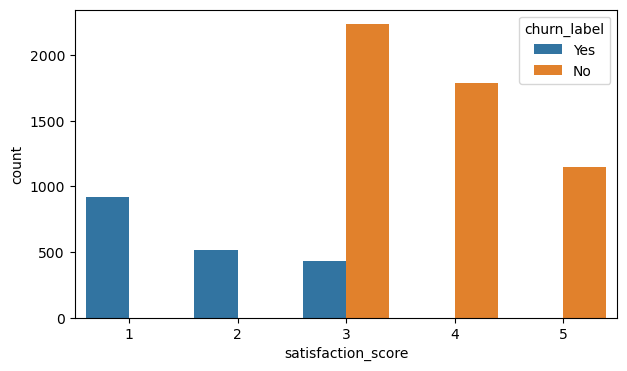

In [47]:
# Satisfaction Score vs Churn
plt.figure(figsize=(7,4))

sns.countplot(
    data=df_clean,
    x="satisfaction_score",
    hue="churn_label"
)

plt.show()

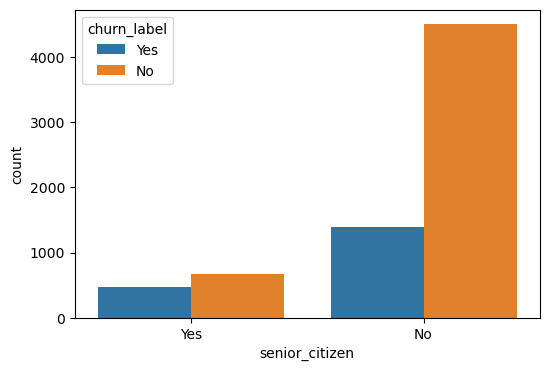

In [48]:
# Senior Citizen vs Churn
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="senior_citizen",
    hue="churn_label"
)

plt.show()

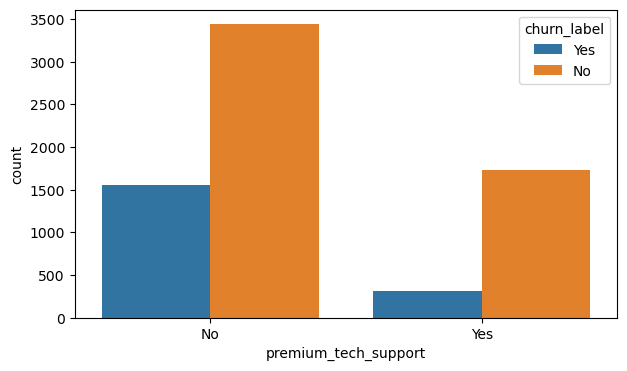

In [49]:
# Tech Support vs Churn
plt.figure(figsize=(7,4))

sns.countplot(
    data=df_clean,
    x="premium_tech_support",
    hue="churn_label"
)

plt.show()

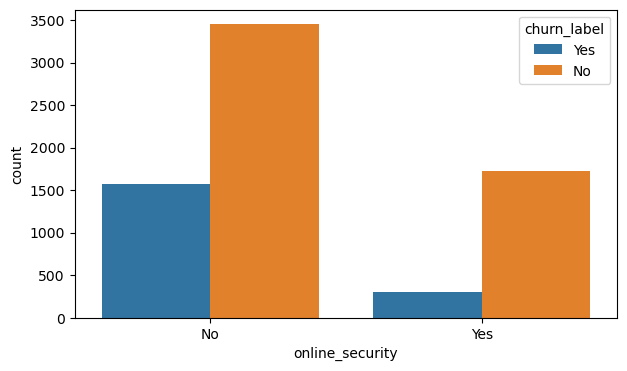

In [50]:
# Online Security vs Churn
plt.figure(figsize=(7,4))

sns.countplot(
    data=df_clean,
    x="online_security",
    hue="churn_label"
)

plt.show()

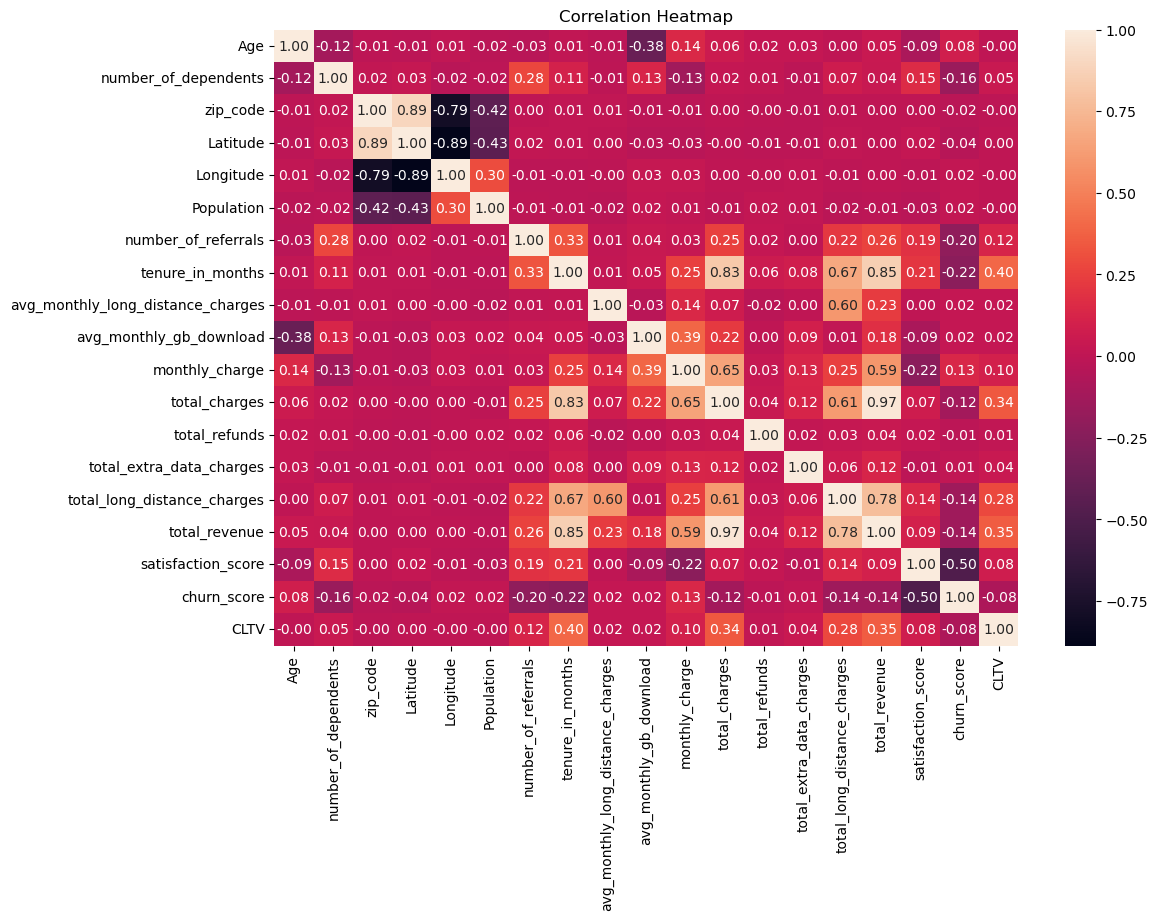

In [51]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_clean.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Outlier Analysis

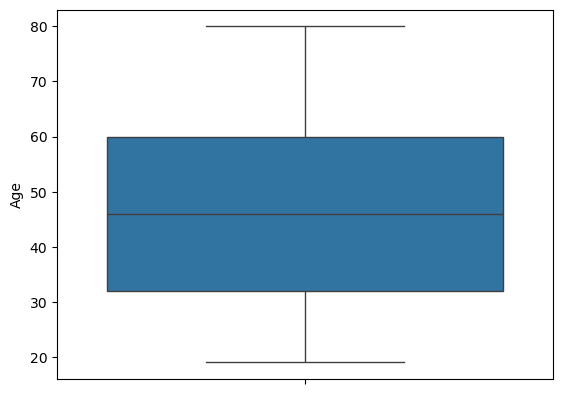

In [53]:
sns.boxplot(y=df_clean["Age"])
plt.show()

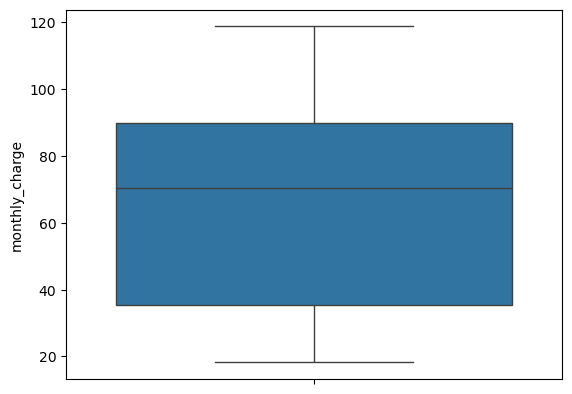

In [54]:
sns.boxplot(y=df_clean["monthly_charge"])
plt.show()

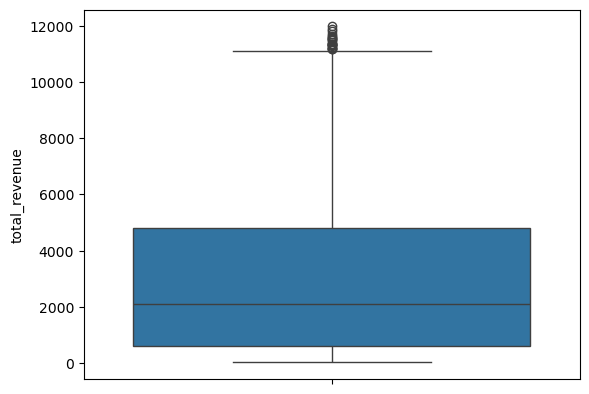

In [55]:
sns.boxplot(y=df_clean["total_revenue"])
plt.show()

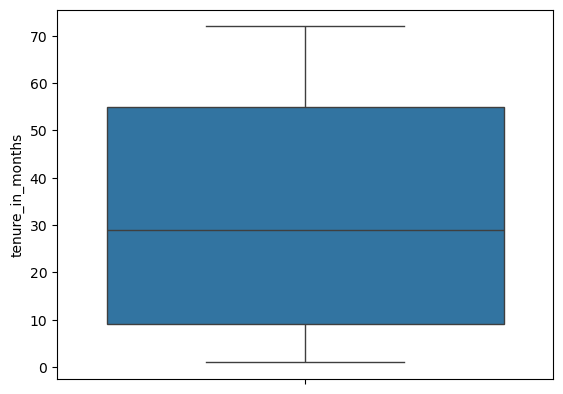

In [56]:
sns.boxplot(y=df_clean["tenure_in_months"])
plt.show()

# Feature Engineering

In [58]:
df_clean.nunique().sort_values()

Quarter                                 1
Country                                 1
State                                   1
premium_tech_support                    2
device_protection_plan                  2
online_backup                           2
online_security                         2
streaming_music                         2
internet_service                        2
multiple_lines                          2
unlimited_data                          2
phone_service                           2
referred_a_friend                       2
streaming_tv                            2
streaming_movies                        2
Dependents                              2
Gender                                  2
churn_label                             2
under_30                                2
senior_citizen                          2
Married                                 2
paperless_billing                       2
payment_method                          3
customer_status                   

**Removing Unnecessary Columns**

In [60]:
leakage_columns = [
    "customer_status",
    "churn_category",
    "churn_reason",
    "churn_score"
]

df_clean.drop(columns=leakage_columns, inplace=True)

In [61]:
df_clean.drop(columns=["customer_id"], inplace=True)

In [62]:
df_clean.drop(columns=["Country","State","Quarter"], inplace=True)

In [63]:
df_clean.drop(columns=["under_30"], inplace=True)

In [64]:
df_clean.drop(columns=[
    "Latitude",
    "Longitude",
    "zip_code"
], inplace=True)

In [65]:
drop_cols = [
    "total_charges",
    "CLTV"
]

df_clean.drop(columns=drop_cols, inplace=True)

**Feature Creation**

In [67]:
# Age Group
df_clean["age_group"] = pd.cut(
    df_clean["Age"],
    bins=[18, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "60+"]
)

In [68]:
# Tenure Group
df_clean["tenure_group"] = pd.cut(
    df_clean["tenure_in_months"],
    bins=[0, 12, 36, 72],
    labels=["New", "Regular", "Loyal"]
)

In [69]:
df_clean.shape

(7043, 38)

In [70]:
df_clean.columns

Index(['Gender', 'Age', 'senior_citizen', 'Married', 'Dependents',
       'number_of_dependents', 'City', 'Population', 'referred_a_friend',
       'number_of_referrals', 'tenure_in_months', 'Offer', 'phone_service',
       'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'internet_type', 'avg_monthly_gb_download',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_tech_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'Contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'satisfaction_score', 'churn_label', 'age_group',
       'tenure_group'],
      dtype='str')

# Train-Test Split

In [72]:
X = df_clean.drop(columns="churn_label")

y = df_clean["churn_label"]

In [73]:
print(X.shape)
print(y.shape)

(7043, 37)
(7043,)


In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (5634, 37)
X_test  : (1409, 37)
y_train : (5634,)
y_test  : (1409,)


# Data Preprocessing

In [78]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [79]:
print("Categorical Features:")
print(categorical_cols)

print("\nNumerical Features:")
print(numerical_cols)

Categorical Features:
['Gender', 'senior_citizen', 'Married', 'Dependents', 'City', 'referred_a_friend', 'Offer', 'phone_service', 'multiple_lines', 'internet_service', 'internet_type', 'online_security', 'online_backup', 'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'Contract', 'paperless_billing', 'payment_method', 'age_group', 'tenure_group']

Numerical Features:
['Age', 'number_of_dependents', 'Population', 'number_of_referrals', 'tenure_in_months', 'avg_monthly_long_distance_charges', 'avg_monthly_gb_download', 'monthly_charge', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue', 'satisfaction_score']


In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [81]:
numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ])

In [82]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            ))])

In [83]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_cols
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_cols
        )])

In [84]:
X_train_processed = preprocessor.fit_transform(X_train)

In [85]:
X_test_processed = preprocessor.transform(X_test)

In [86]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 1174)
(1409, 1174)


# Model Training

## Logistic Regression

In [89]:
X = df_clean.drop(columns="churn_label")

y = df_clean["churn_label"]

In [90]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [91]:
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [92]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [93]:
numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ])

In [94]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            ))])

In [95]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_cols
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_cols
        )])

In [96]:
X_train_processed = preprocessor.fit_transform(X_train)

In [97]:
X_test_processed = preprocessor.transform(X_test)

In [98]:
from sklearn.linear_model import LogisticRegression
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

In [99]:
lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](37,)","['Gender','Age','senior_citizen',...,'satisfaction_score','age_group', 'tenure_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,37
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [100]:
lr_pred = lr_model.predict(X_test)

In [101]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, lr_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9630943931866572


In [102]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

          No       0.96      0.99      0.98      1035
         Yes       0.96      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [103]:
from sklearn.metrics import roc_auc_score

lr_prob = lr_model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, lr_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.9918442739414606


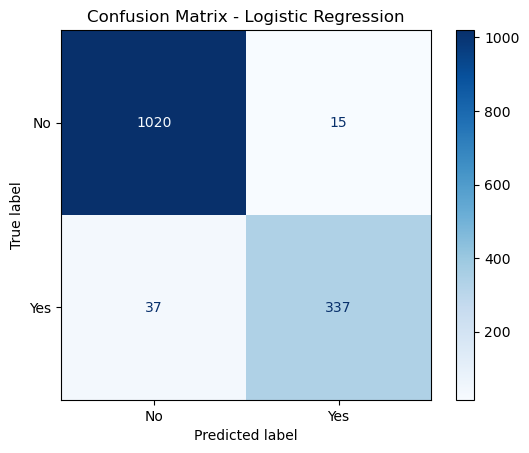

In [104]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Decision Tree

In [106]:
from sklearn.tree import DecisionTreeClassifier

In [107]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [108]:
dt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](37,)","['Gender','Age','senior_citizen',...,'satisfaction_score','age_group', 'tenure_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,37
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [109]:
dt_pred = dt_model.predict(X_test)

In [110]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, dt_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9559971611071683


In [111]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

          No       0.96      0.98      0.97      1035
         Yes       0.93      0.90      0.92       374

    accuracy                           0.96      1409
   macro avg       0.95      0.94      0.94      1409
weighted avg       0.96      0.96      0.96      1409



In [112]:
from sklearn.metrics import roc_auc_score

dt_prob = dt_model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, dt_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.9384574646722984


## Random Forest

In [114]:
from sklearn.ensemble import RandomForestClassifier

In [115]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [116]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](37,)","['Gender','Age','senior_citizen',...,'satisfaction_score','age_group', 'tenure_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,37
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [117]:
rf_pred = rf_model.predict(X_test)

In [118]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, rf_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9368346344925479


In [119]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

          No       0.93      0.98      0.96      1035
         Yes       0.95      0.81      0.87       374

    accuracy                           0.94      1409
   macro avg       0.94      0.90      0.91      1409
weighted avg       0.94      0.94      0.94      1409



In [120]:
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, rf_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.9697667209176161


## Xgboost

In [122]:
from xgboost import XGBClassifier

In [123]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [124]:
print(label_encoder.classes_)

['No' 'Yes']


In [125]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [126]:
xgb_model.fit(X_train, y_train_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](37,)","['Gender','Age','senior_citizen',...,'satisfaction_score','age_group', 'tenure_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,37
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [127]:
xgb_pred = xgb_model.predict(X_test)

In [128]:
xgb_pred = label_encoder.inverse_transform(xgb_pred)

In [129]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, xgb_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9630943931866572


In [130]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

          No       0.96      0.99      0.98      1035
         Yes       0.96      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [131]:
from sklearn.metrics import roc_auc_score

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test_encoded, xgb_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.9903149138443257


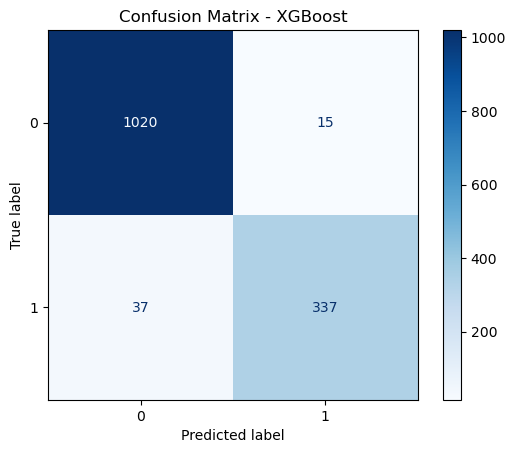

In [132]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test_encoded,
    cmap="Blues"
)

plt.title("Confusion Matrix - XGBoost")
plt.show()

# Hyperparameter Tuning

## Logistic Regression

In [135]:
from sklearn.model_selection import GridSearchCV

In [136]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"]
}

In [137]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

In [138]:
grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1
)

In [139]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [140]:
print(grid_search.best_params_)

{'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}


In [141]:
print(grid_search.best_score_)

0.9632336998867826


In [142]:
best_lr = grid_search.best_estimator_

In [143]:
lr_pred = best_lr.predict(X_test)

In [144]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy:", accuracy)

Accuracy: 0.964513839602555


In [145]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

          No       0.97      0.99      0.98      1035
         Yes       0.96      0.90      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.95      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [146]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_test_encoded = le.fit_transform(y_test)

In [147]:
from sklearn.metrics import roc_auc_score

lr_prob = best_lr.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test_encoded, lr_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.9925727866904337


## Xgboost

In [149]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [150]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.1, 0.2]
}

In [151]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

In [152]:
grid_search.fit(X_train, y_train_encoded)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.01, 0.1, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True

In [153]:
print(grid_search.best_params_)

{'classifier__learning_rate': 0.2, 'classifier__max_depth': 5, 'classifier__n_estimators': 300}


In [154]:
print(grid_search.best_score_)

0.9301196727850318


In [155]:
best_xgb = grid_search.best_estimator_

In [156]:
xgb_pred_encoded = best_xgb.predict(X_test)

xgb_pred = label_encoder.inverse_transform(xgb_pred_encoded)

In [157]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, xgb_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9609652235628106


In [158]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

          No       0.97      0.98      0.97      1035
         Yes       0.95      0.90      0.92       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [159]:
from sklearn.metrics import roc_auc_score

xgb_prob = best_xgb.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test_encoded, xgb_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.988336045880803


# Feature Importance

In [161]:
feature_names = best_lr.named_steps["preprocessor"].get_feature_names_out()

In [162]:
len(feature_names)

1174

In [163]:
coefficients = best_lr.named_steps["classifier"].coef_[0]

In [164]:
len(coefficients)

1174

In [165]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [166]:
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

In [167]:
feature_importance.head(15)

,Feature,Coefficient
873,cat__City_San Diego,1.687907
912,cat__City_Santa Rosa,1.508077
874,cat__City_San Dimas,1.481620
1128,cat__Offer_Offer A,1.357158
336,cat__City_Fallbrook,1.299141
512,cat__City_La Palma,1.110769
1159,cat__Contract_Month-to-Month,0.914751
129,cat__City_Brea,0.870997
7,num__monthly_charge,0.587918
371,cat__City_Fresno,0.585278


In [168]:
fi = feature_importance[
    ~feature_importance["Feature"].str.contains("City")
]

In [169]:
fi.head()

,Feature,Coefficient
1128,cat__Offer_Offer A,1.357158
1159,cat__Contract_Month-to-Month,0.914751
7,num__monthly_charge,0.587918
1132,cat__Offer_Offer E,0.300099
1,num__number_of_dependents,0.288741


In [170]:
positive_features = fi.sort_values(
    by="Coefficient",
    ascending=False
)

positive_features.head(10)

,Feature,Coefficient
1128,cat__Offer_Offer A,1.357158
1159,cat__Contract_Month-to-Month,0.914751
7,num__monthly_charge,0.587918
1132,cat__Offer_Offer E,0.300099
1,num__number_of_dependents,0.288741
10,num__total_long_distance_charges,0.244554
0,num__Age,0.109386
2,num__Population,0.091448
6,num__avg_monthly_gb_download,0.026085
9,num__total_extra_data_charges,0.016696


In [171]:
negative_features = fi.sort_values(
    by="Coefficient",
    ascending=True
)

negative_features.head(10)

,Feature,Coefficient
12,num__satisfaction_score,-9.820522
1144,cat__online_security_Yes,-3.002580
20,cat__Dependents_Yes,-2.273859
3,num__number_of_referrals,-2.134076
1125,cat__referred_a_friend_No,-1.422927
1134,cat__phone_service_Yes,-1.031768
1161,cat__Contract_Two Year,-0.926968
4,num__tenure_in_months,-0.789344
1155,cat__streaming_music_No,-0.686112
1150,cat__premium_tech_support_Yes,-0.630784


In [172]:
top_features = fi.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
).head(20)

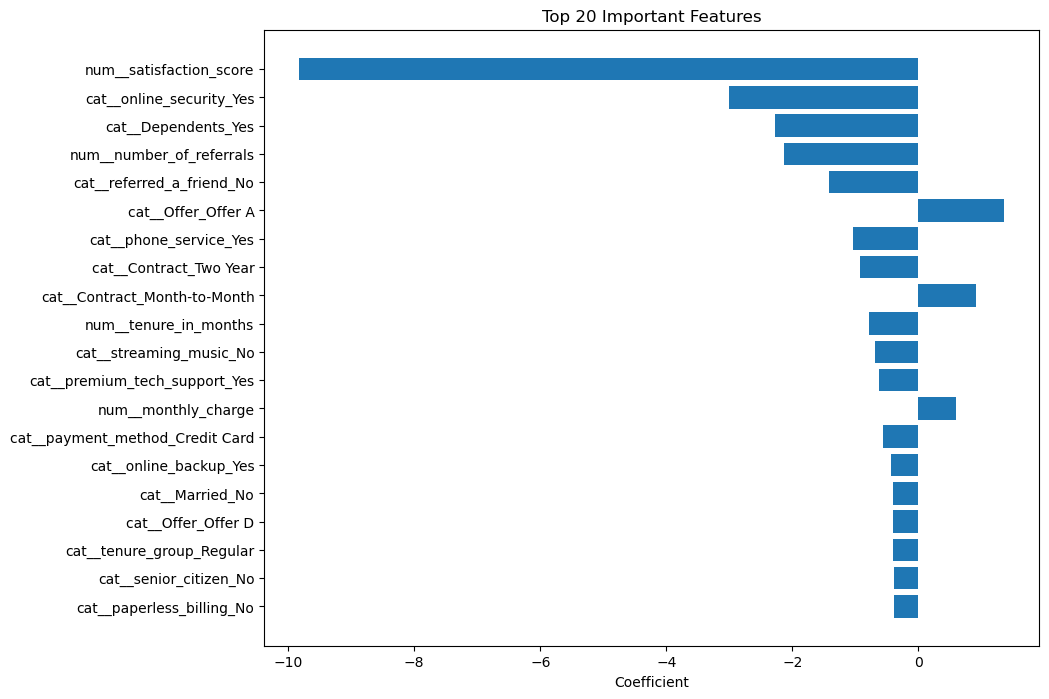

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.title("Top 20 Important Features")

plt.gca().invert_yaxis()

plt.show()

# Saving Clean Data

In [175]:
df_clean["Predicted_Churn"] = best_lr.predict(X)

df_clean["Churn_Probability"] = best_lr.predict_proba(X)[:, 1]

In [176]:
df_clean["Risk_Level"] = pd.cut(
    df_clean["Churn_Probability"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [177]:
df_clean.to_csv("customer_churn_predictions.csv", index=False)

# Saving Best Model

In [179]:
import joblib

joblib.dump(best_lr, "churn_prediction_model.pkl")

['churn_prediction_model.pkl']